In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/SF_Air_Traffic_Passenger_Statistics.csv")

In [3]:
df = pd.read_csv("data/SF_Air_Traffic_Passenger_Statistics.csv")

In [4]:
print(df.shape)
df.head()

(40450, 15)


,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,"31,432",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,"31,353",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,"2,518",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,"1,324",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,"1,198",2026/08/20 01:00:20 PM,2026/08/22 03:04:26 PM


In [5]:
df["Passenger Count"] = (
    df["Passenger Count"]
    .str.replace(",", "")
    .astype(int)
)

In [6]:
print(df["Passenger Count"].dtype)

int64


In [7]:
df["Activity Period Start Date"] = pd.to_datetime(
    df["Activity Period Start Date"]
)

In [8]:
print(df["Activity Period Start Date"].dtype)

datetime64[us]


In [9]:
df.isnull().sum()

Activity Period                  0
Activity Period Start Date       0
Operating Airline                0
Operating Airline IATA Code    316
Published Airline                0
Published Airline IATA Code    316
GEO Summary                      0
GEO Region                       0
Activity Type Code               0
Price Category Code              0
Terminal                         0
Boarding Area                    0
Passenger Count                  0
data_as_of                       0
data_loaded_at                   0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
monthly_df = (
    df.groupby("Activity Period Start Date")["Passenger Count"]
    .sum()
    .reset_index()
)

In [12]:
monthly_df.columns = ["Month", "Passenger Count"]

In [13]:
monthly_df = monthly_df.sort_values("Month")

In [14]:
monthly_df.head(10)

,Month,Passenger Count
0,1999-07-01,3976746
1,1999-08-01,3972694
2,1999-09-01,3341964
3,1999-10-01,3468846
4,1999-11-01,3145240
5,1999-12-01,3077142
6,2000-01-01,2781129
7,2000-02-01,2725393
8,2000-03-01,3294029
9,2000-04-01,3392617


In [15]:
print(monthly_df.head(10))

       Month  Passenger Count
0 1999-07-01          3976746
1 1999-08-01          3972694
2 1999-09-01          3341964
3 1999-10-01          3468846
4 1999-11-01          3145240
5 1999-12-01          3077142
6 2000-01-01          2781129
7 2000-02-01          2725393
8 2000-03-01          3294029
9 2000-04-01          3392617


In [16]:
print(monthly_df["Month"].min())
print(monthly_df["Month"].max())

1999-07-01 00:00:00
2026-06-01 00:00:00


In [17]:
print("Number of months:", monthly_df["Month"].nunique())
print("Number of rows:", len(monthly_df))

Number of months: 324
Number of rows: 324


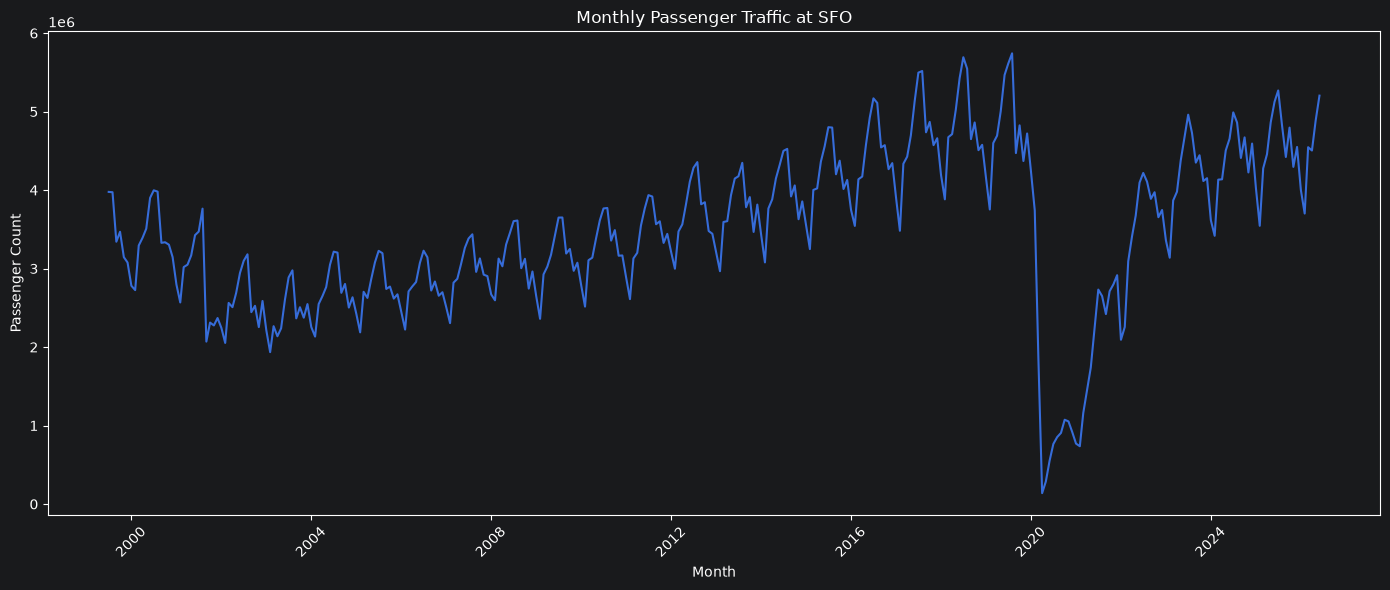

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_df["Month"],
    monthly_df["Passenger Count"]
)

plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.title("Monthly Passenger Traffic at SFO")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
monthly_df["Month_Number"] = monthly_df["Month"].dt.month

In [20]:
seasonal_avg = (
    monthly_df.groupby("Month_Number")["Passenger Count"]
    .mean()
)

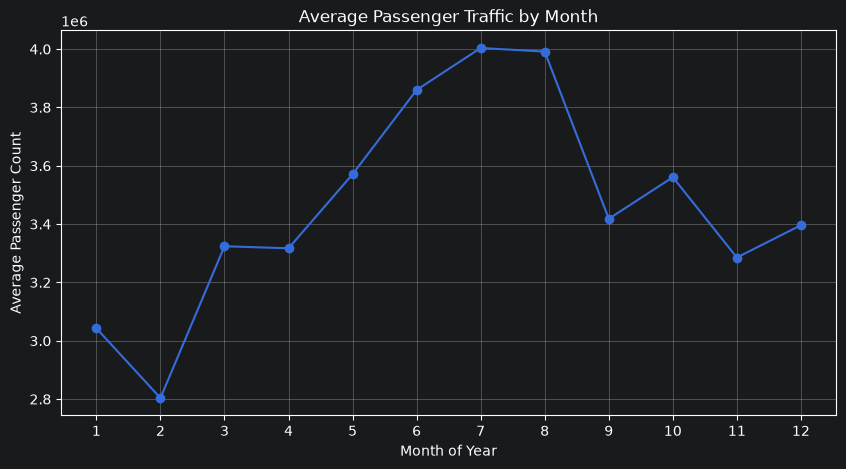

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    seasonal_avg.index,
    seasonal_avg.values,
    marker="o"
)

plt.xlabel("Month of Year")
plt.ylabel("Average Passenger Count")
plt.title("Average Passenger Traffic by Month")

plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [22]:
print("Highest passenger months:")
print(
    monthly_df.nlargest(10, "Passenger Count")[
        ["Month", "Passenger Count"]
    ]
)

Highest passenger months:
         Month  Passenger Count
241 2019-08-01          5742437
228 2018-07-01          5692572
240 2019-07-01          5612312
229 2018-08-01          5545859
217 2017-08-01          5516837
216 2017-07-01          5496516
239 2019-06-01          5466688
227 2018-06-01          5427144
312 2025-07-01          5269263
323 2026-06-01          5203386


In [23]:
print("Lowest passenger months:")
print(
    monthly_df.nsmallest(10, "Passenger Count")[
        ["Month", "Passenger Count"]
    ]
)

Lowest passenger months:
         Month  Passenger Count
249 2020-04-01           138817
250 2020-05-01           286570
251 2020-06-01           555119
259 2021-02-01           736324
252 2020-07-01           765274
258 2021-01-01           769908
253 2020-08-01           852578
254 2020-09-01           905992
257 2020-12-01           918723
256 2020-11-01          1052317


In [24]:
monthly_df = monthly_df.drop(columns=["Month_Number"])

In [25]:
monthly_df.head()

,Month,Passenger Count
0,1999-07-01,3976746
1,1999-08-01,3972694
2,1999-09-01,3341964
3,1999-10-01,3468846
4,1999-11-01,3145240


In [26]:
monthly_df.tail()

,Month,Passenger Count
319,2026-02-01,3701198
320,2026-03-01,4546149
321,2026-04-01,4504215
322,2026-05-01,4884065
323,2026-06-01,5203386


In [27]:
print(monthly_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Month            324 non-null    datetime64[us]
 1   Passenger Count  324 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 5.2 KB
None


In [29]:
monthly_df.to_csv(
    "data/processed/monthly_passenger_demand.csv",
    index=False
)